# 46.2 · Block matching from scratch

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain block matching from scratch using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[16 · Camera and Calibration](../../16-camera-and-calibration/README.md), [44 · 3D Computer Vision](../../44-3d-computer-vision/README.md), [45 · Depth Estimation](../../45-depth-estimation/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Stereo vision searches for corresponding image points between cameras. Rectification makes ideal matches lie on the same row, reducing a two-dimensional search to a horizontal disparity search. Matching still struggles with occlusion, textureless areas and repeated patterns.

## 2. Intuition

Block matching aggregates a photometric difference over a neighborhood for each candidate disparity and selects the minimum. Larger windows stabilize noisy texture but blur depth boundaries. Costs may use absolute difference, squared difference or robust descriptors. The reference uses absolute differences and a box-filter aggregation.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 46
LESSON = 1
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
d^*(p)=\arg\min_d\sum_{q\in W(p)}|L(q)-R(q-(d,0))|
$$

L and R are rectified images, W(p) a neighborhood around pixel p and d a candidate disparity. The selected disparity minimizes local absolute intensity difference. Candidate costs [9,2,7] select the second candidate.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
candidate_disparities = np.array([0, 1, 2])
costs = np.array([9.0, 2.0, 7.0])
best = candidate_disparities[costs.argmin()]
assert best == 1
print(best)

1


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The reference constructs a cost volume over integer shifts and chooses its minimum. SGBM provides an optimized comparison; error is evaluated only in an interior region with valid synthetic correspondences.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def stereo(lesson=0, seed=42, amount=1.0):
    rng = np.random.default_rng(seed)
    left = rng.integers(0, 256, (80, 160), dtype="uint8")
    d = int(np.clip(round(8 * amount), 2, 14))
    right = np.zeros_like(left)
    right[:, :-d] = left[:, d:]
    # Compare integer disparity hypotheses after rectification; invalid left columns excluded.
    costs = []
    for candidate in range(16):
        shifted = np.zeros_like(right)
        if candidate:
            shifted[:, candidate:] = right[:, :-candidate]
        else:
            shifted[:] = right
        error = np.abs(left.astype(float) - shifted.astype(float))
        costs.append(cv2.boxFilter(error, -1, (7, 7), normalize=True))
    reference = np.argmin(costs, axis=0)
    matcher = cv2.StereoSGBM_create(
        minDisparity=0, numDisparities=16, blockSize=5, P1=8 * 25, P2=32 * 25, uniquenessRatio=5
    )
    prediction = matcher.compute(left, right).astype(float) / 16
    roi = (slice(8, -8), slice(24, -16))
    return Result(
        "46 · Rectified stereo matching",
        {
            "Left": left,
            "Right": right,
            "Block matching disparity": reference,
            "SGBM disparity": prediction,
        },
        metrics={
            "true_disparity_px": d,
            "block_mae_px": float(np.abs(reference[roi] - d).mean()),
            "sgbm_mae_px": float(np.abs(prediction[roi] - d).mean()),
        },
        notes="One fronto-parallel plane with random texture, no distortion and one known disparity. Dividing OpenCV fixed-point disparity by 16 is essential. Occlusions and textureless surfaces are not solved here.",
    )

{
  "true_disparity_px": 8,
  "block_mae_px": 0.0,
  "sgbm_mae_px": 0.0
}
One fronto-parallel plane with random texture, no distortion and one known disparity. Dividing OpenCV fixed-point disparity by 16 is essential. Occlusions and textureless surfaces are not solved here.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/geometry.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.geometry import disparity_to_depth

display(Code(inspect.getsource(disparity_to_depth), language="python"))

def disparity_to_depth(disparity, focal_px, baseline):
    """Z=fB/d. Invalid/nonpositive disparity returns NaN, not invented distance."""
    disparity = np.asarray(disparity, float)
    if focal_px <= 0 or baseline <= 0:
        raise ValueError("Focal length and baseline must be positive.")
    return np.divide(
        focal_px * baseline, disparity, out=np.full_like(disparity, np.nan), where=disparity > 0
    )

## 8. Experiment

Replace random texture with a flat patch and inspect ambiguity in the full cost curve. Add an occluder visible to only one camera.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "true_disparity_px": 8,
    "block_mae_px": 0.0,
    "sgbm_mae_px": 0.0
  },
  "second_seed": {
    "true_disparity_px": 8,
    "block_mae_px": 0.0,
    "sgbm_mae_px": 0.0
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

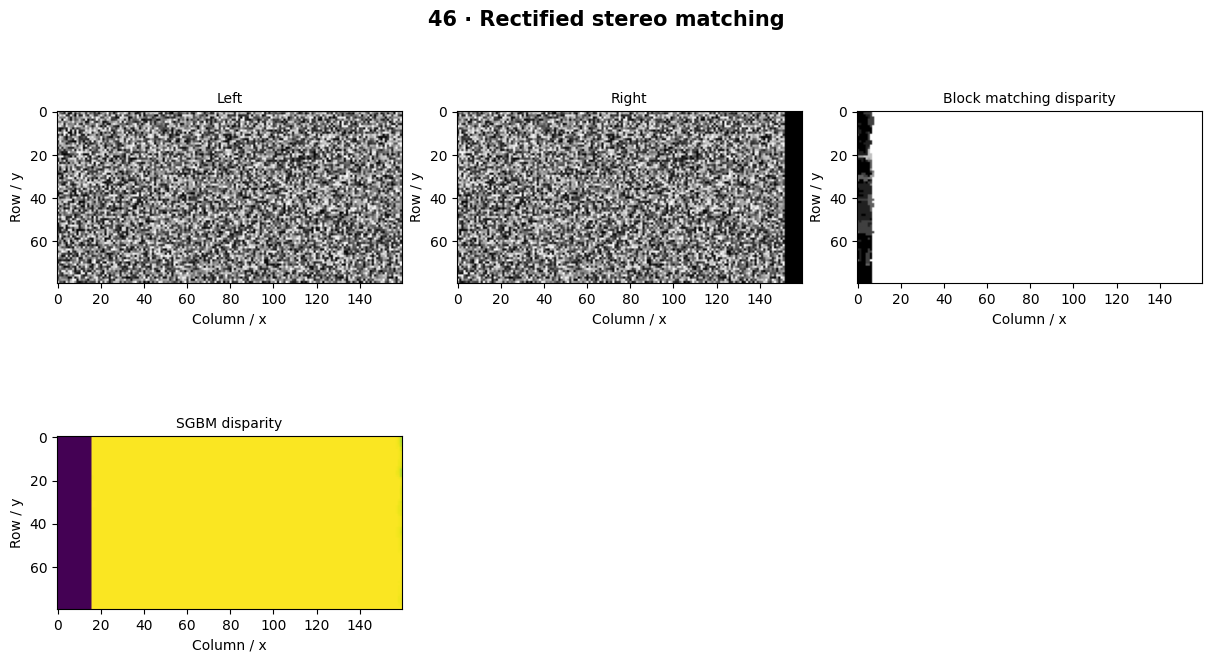

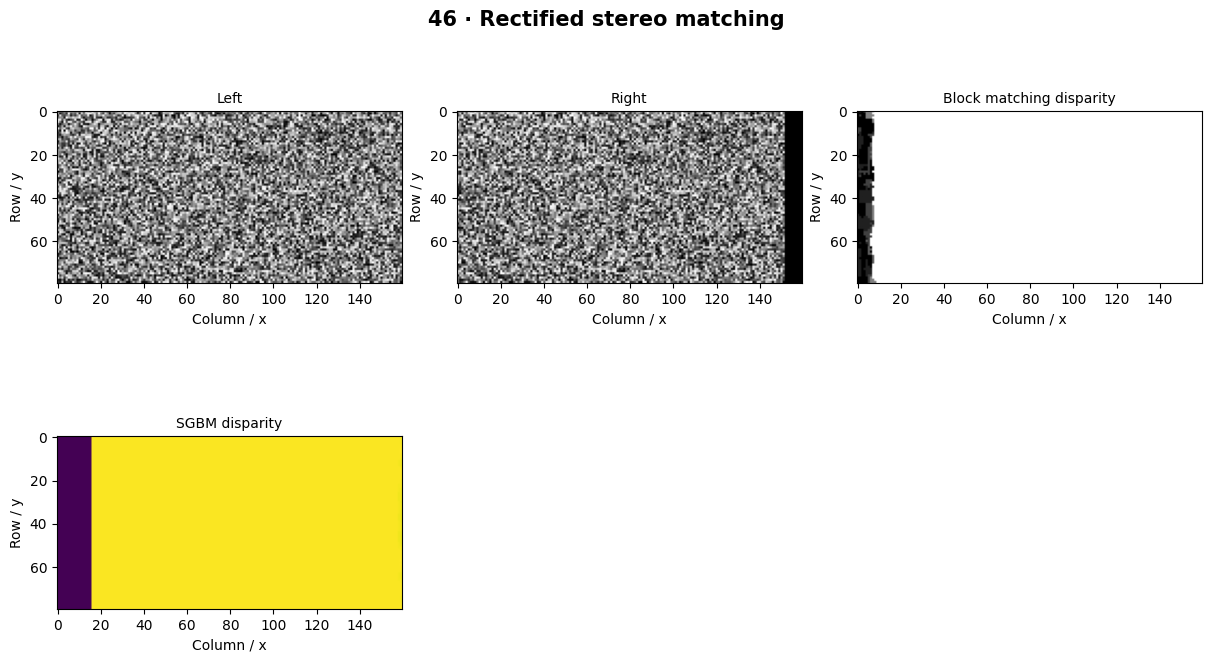

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Stereo Depth Toolkit**. Convert calibrated disparity into depth with valid masks. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

Using raw SGBM integer output as pixels makes depth wrong by a factor of 16. Rectification does not create missing correspondence in occluded regions.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Replace random texture with a flat patch and inspect ambiguity in the full cost curve. Add an occluder visible to only one camera.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a stereo-depth pipeline with calibration files, invalid masks and a left-right consistency diagnostic.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Block matching aggregates a photometric difference over a neighborhood for each candidate disparity and selects the minimum. Larger windows stabilize noisy texture but blur depth boundaries. Costs may use absolute difference, squared difference or robust descriptors. The reference uses absolute differences and a box-filter aggregation.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **SGBM and consistency checks** in this chapter.

[Primary reference](https://docs.opencv.org/4.x/d2/d85/classcv_1_1StereoSGBM.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)